In [2]:
from google.colab import drive
import os

# Mount Google Drive (force remount to avoid "already mounted" issues)
drive.mount('/content/drive', force_remount=True)

# Base directory — your Augumented dataset folder (note spelling: 'Augumented')
base_dir = '/content/drive/MyDrive/Augumented'
classes = ['GERD', 'GERD Normal']

# Verify dataset folders
if not os.path.exists(base_dir):
    raise FileNotFoundError(f"❌ Base directory not found: {base_dir}")

print(f"✅ Base directory found: {base_dir}")
print("📁 Subfolders:")
for cls in classes:
    path = os.path.join(base_dir, cls)
    if os.path.exists(path):
        print(f"   - {cls}: {len([f for f in os.listdir(path) if os.path.isfile(os.path.join(path,f))])} images")
    else:
        print(f"   ⚠️ Missing: {cls}")


Mounted at /content/drive
✅ Base directory found: /content/drive/MyDrive/Augumented
📁 Subfolders:
   - GERD: 5844 images
   - GERD Normal: 6618 images


In [3]:
import os, shutil
from sklearn.model_selection import train_test_split

split_base = '/content/dataset_split'
os.makedirs(split_base, exist_ok=True)
for split in ['train', 'test']:
    for cls in classes:
        os.makedirs(os.path.join(split_base, split, cls), exist_ok=True)

def split_data(source_dir, dest_dir, test_size=0.2, seed=42):
    files = [f for f in os.listdir(source_dir) if os.path.isfile(os.path.join(source_dir, f))]
    # sort for reproducibility
    files.sort()
    train_files, test_files = train_test_split(files, test_size=test_size, random_state=seed, shuffle=True)
    cls_name = os.path.basename(source_dir)
    print(f"📁 {cls_name} → Train: {len(train_files)}, Test: {len(test_files)}")
    for name, file_list in zip(['train','test'], [train_files, test_files]):
        for file in file_list:
            src = os.path.join(source_dir, file)
            dst = os.path.join(dest_dir, name, cls_name, file)
            shutil.copy2(src, dst)

# Run splitting
for cls in classes:
    cls_dir = os.path.join(base_dir, cls)
    if not os.path.exists(cls_dir):
        print(f"⚠️ Skipping missing folder: {cls_dir}")
        continue
    split_data(cls_dir, split_base)

print('\n✅ Data split complete. New dataset at:', split_base)


📁 GERD → Train: 4675, Test: 1169
📁 GERD Normal → Train: 5294, Test: 1324

✅ Data split complete. New dataset at: /content/dataset_split


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = '/content/dataset_split/train'
test_dir  = '/content/dataset_split/test'

# Strong data augmentation for endoscopic images
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

print('✅ Data generators ready. Classes:', train_gen.class_indices)


Found 9969 images belonging to 2 classes.
Found 2493 images belonging to 2 classes.
✅ Data generators ready. Classes: {'GERD': 0, 'GERD Normal': 1}


In [5]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load base VGG19
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze first 12 layers, fine-tune the rest (your original setting)
for layer in base_model.layers[:12]:
    layer.trainable = False
for layer in base_model.layers[12:]:
    layer.trainable = True

print(f"🔓 Number of trainable layers: {sum([1 for l in base_model.layers if l.trainable])}")

# Classifier head (same as your code)
x = GlobalAveragePooling2D(name='gap')(base_model.output)
x = Dense(512, activation='relu', name='fc1')(x)
x = BatchNormalization(name='bn1')(x)
x = Dropout(0.4, name='drop1')(x)
x = Dense(256, activation='relu', name='fc2')(x)
x = BatchNormalization(name='bn2')(x)
x = Dropout(0.3, name='drop2')(x)
output = Dense(1, activation='sigmoid', name='output')(x)

model = Model(inputs=base_model.input, outputs=output, name='VGG19_GERD_Tuned')

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
🔓 Number of trainable layers: 10


Model: "VGG19_GERD_Tuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 512)            │         2,04

 Total params: 20,421,697 (77.90 MB)

 Trainable params: 18,094,593 (69.03 MB)

 Non-trainable params: 2,327,104 (8.88 MB)

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

EPOCHS = 40
MODEL_PATH = '/content/vgg19_gerd_best_95acc.h5'

early_stop = EarlyStopping(monitor='val_accuracy',
                           patience=6,
                           restore_best_weights=True,
                           verbose=1)
checkpoint = ModelCheckpoint(MODEL_PATH,
                             monitor='val_accuracy',
                             save_best_only=True,
                             verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy',
                              factor=0.2,
                              patience=3,
                              min_lr=1e-7,
                              verbose=1)

# Class weights (helps if GERD / Normal are imbalanced)
classes_list = np.unique(train_gen.classes)
class_weights = compute_class_weight('balanced',
                                     classes=classes_list,
                                     y=train_gen.classes)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print('Class weights:', class_weight_dict)

history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

print('\n✅ Training finished. Best model saved to:', MODEL_PATH)


Class weights: {0: np.float64(1.0662032085561497), 1: np.float64(0.9415375897242161)}


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 637ms/step - accuracy: 0.5695 - loss: 0.8442
Epoch 1: val_accuracy improved from -inf to 0.64460, saving model to /content/vgg19_gerd_best_95acc.h5


312/312 ━━━━━━━━━━━━━━━━━━━━ 262s 756ms/step - accuracy: 0.5695 - loss: 0.8441 - val_accuracy: 0.6446 - val_loss: 0.6340 - learning_rate: 1.0000e-05
Epoch 2/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.6492 - loss: 0.7137
Epoch 2: val_accuracy did not improve from 0.64460
312/312 ━━━━━━━━━━━━━━━━━━━━ 205s 655ms/step - accuracy: 0.6492 - loss: 0.7137 - val_accuracy: 0.6045 - val_loss: 1.1083 - learning_rate: 1.0000e-05
Epoch 3/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 595ms/step - accuracy: 0.6687 - loss: 0.6951
Epoch 3: val_accuracy improved from 0.64460 to 0.68512, saving model to /content/vgg19_gerd_best_95acc.h5


312/312 ━━━━━━━━━━━━━━━━━━━━ 204s 653ms/step - accuracy: 0.6688 - loss: 0.6950 - val_accuracy: 0.6851 - val_loss: 0.8074 - learning_rate: 1.0000e-05
Epoch 4/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.7154 - loss: 0.6143
Epoch 4: val_accuracy improved from 0.68512 to 0.77216, saving model to /content/vgg19_gerd_best_95acc.h5


...

312/312 ━━━━━━━━━━━━━━━━━━━━ 201s 644ms/step - accuracy: 0.8622 - loss: 0.3363 - val_accuracy: 0.8857 - val_loss: 0.2762 - learning_rate: 1.0000e-05
Epoch 15/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.8694 - loss: 0.3196
Epoch 15: val_accuracy improved from 0.88568 to 0.89089, saving model to /content/vgg19_gerd_best_95acc.h5


312/312 ━━━━━━━━━━━━━━━━━━━━ 201s 642ms/step - accuracy: 0.8694 - loss: 0.3196 - val_accuracy: 0.8909 - val_loss: 0.2652 - learning_rate: 1.0000e-05
Epoch 16/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.8790 - loss: 0.2986
Epoch 16: val_accuracy improved from 0.89089 to 0.89972, saving model to /content/vgg19_gerd_best_95acc.h5


312/312 ━━━━━━━━━━━━━━━━━━━━ 200s 640ms/step - accuracy: 0.8790 - loss: 0.2986 - val_accuracy: 0.8997 - val_loss: 0.2381 - learning_rate: 1.0000e-05
Epoch 17/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.8904 - loss: 0.2701
Epoch 17: val_accuracy did not improve from 0.89972
312/312 ━━━━━━━━━━━━━━━━━━━━ 200s 638ms/step - accuracy: 0.8904 - loss: 0.2701 - val_accuracy: 0.8933 - val_loss: 0.2463 - learning_rate: 1.0000e-05
Epoch 18/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.8976 - loss: 0.2481
Epoch 18: val_accuracy did not improve from 0.89972
312/312 ━━━━━━━━━━━━━━━━━━━━ 210s 665ms/step - accuracy: 0.8975 - loss: 0.2482 - val_accuracy: 0.8937 - val_loss: 0.2529 - learning_rate: 1.0000e-05
Epoch 19/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.8936 - loss: 0.2611
Epoch 19: val_accuracy did not improve from 0.89972

Epoch 19: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
312/312 ━━━━━━━━━━━━━━━━━━━━ 212s 680ms/step - accu

312/312 ━━━━━━━━━━━━━━━━━━━━ 209s 671ms/step - accuracy: 0.9189 - loss: 0.2066 - val_accuracy: 0.9378 - val_loss: 0.1684 - learning_rate: 2.0000e-06
Epoch 21/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - accuracy: 0.9283 - loss: 0.1870
Epoch 21: val_accuracy did not improve from 0.93783
312/312 ━━━━━━━━━━━━━━━━━━━━ 209s 671ms/step - accuracy: 0.9283 - loss: 0.1870 - val_accuracy: 0.9170 - val_loss: 0.2017 - learning_rate: 2.0000e-06
Epoch 22/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - accuracy: 0.9324 - loss: 0.1729
Epoch 22: val_accuracy improved from 0.93783 to 0.93943, saving model to /content/vgg19_gerd_best_95acc.h5


312/312 ━━━━━━━━━━━━━━━━━━━━ 211s 676ms/step - accuracy: 0.9324 - loss: 0.1729 - val_accuracy: 0.9394 - val_loss: 0.1604 - learning_rate: 2.0000e-06
Epoch 23/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 614ms/step - accuracy: 0.9367 - loss: 0.1626
Epoch 23: val_accuracy did not improve from 0.93943
312/312 ━━━━━━━━━━━━━━━━━━━━ 209s 670ms/step - accuracy: 0.9366 - loss: 0.1626 - val_accuracy: 0.9222 - val_loss: 0.1899 - learning_rate: 2.0000e-06
Epoch 24/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 622ms/step - accuracy: 0.9334 - loss: 0.1688
Epoch 24: val_accuracy did not improve from 0.93943
312/312 ━━━━━━━━━━━━━━━━━━━━ 212s 678ms/step - accuracy: 0.9334 - loss: 0.1688 - val_accuracy: 0.9190 - val_loss: 0.2068 - learning_rate: 2.0000e-06
Epoch 25/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 633ms/step - accuracy: 0.9381 - loss: 0.1639
Epoch 25: val_accuracy did not improve from 0.93943

Epoch 25: ReduceLROnPlateau reducing learning rate to 3.999999989900971e-07.
312/312 ━━━━━━━━━━━━━━━━━━━━ 215s 689ms/step - accur

In [7]:
# Unfreeze more layers & train with a smaller learning rate
for layer in base_model.layers[:8]:
    layer.trainable = False
for layer in base_model.layers[8:]:
    layer.trainable = True

model.compile(optimizer=Adam(learning_rate=1e-6),
              loss='binary_crossentropy',
              metrics=['accuracy'])

fine_tune_epochs = 15

history_ft = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=fine_tune_epochs,
    callbacks=[early_stop, checkpoint, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

print('\n✅ Fine-tuning finished. Best model saved to:', MODEL_PATH)


Epoch 1/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 673ms/step - accuracy: 0.9302 - loss: 0.1728
Epoch 1: val_accuracy did not improve from 0.93943
312/312 ━━━━━━━━━━━━━━━━━━━━ 245s 735ms/step - accuracy: 0.9302 - loss: 0.1728 - val_accuracy: 0.9254 - val_loss: 0.1853 - learning_rate: 1.0000e-06
Epoch 2/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 661ms/step - accuracy: 0.9384 - loss: 0.1592
Epoch 2: val_accuracy did not improve from 0.93943
312/312 ━━━━━━━━━━━━━━━━━━━━ 224s 717ms/step - accuracy: 0.9384 - loss: 0.1592 - val_accuracy: 0.9314 - val_loss: 0.1750 - learning_rate: 1.0000e-06
Epoch 3/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - accuracy: 0.9426 - loss: 0.1461
Epoch 3: val_accuracy did not improve from 0.93943
312/312 ━━━━━━━━━━━━━━━━━━━━ 217s 696ms/step - accuracy: 0.9426 - loss: 0.1461 - val_accuracy: 0.9302 - val_loss: 0.1761 - learning_rate: 1.0000e-06
Epoch 4/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 654ms/step - accuracy: 0.9412 - loss: 0.1515
Epoch 4: val_accuracy improved from 0.93943 to 0

312/312 ━━━━━━━━━━━━━━━━━━━━ 222s 712ms/step - accuracy: 0.9412 - loss: 0.1516 - val_accuracy: 0.9398 - val_loss: 0.1508 - learning_rate: 1.0000e-06
Epoch 5/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - accuracy: 0.9444 - loss: 0.1491
Epoch 5: val_accuracy improved from 0.93983 to 0.94184, saving model to /content/vgg19_gerd_best_95acc.h5


312/312 ━━━━━━━━━━━━━━━━━━━━ 219s 700ms/step - accuracy: 0.9444 - loss: 0.1491 - val_accuracy: 0.9418 - val_loss: 0.1440 - learning_rate: 1.0000e-06
Epoch 6/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.9446 - loss: 0.1469
Epoch 6: val_accuracy improved from 0.94184 to 0.94665, saving model to /content/vgg19_gerd_best_95acc.h5


312/312 ━━━━━━━━━━━━━━━━━━━━ 222s 709ms/step - accuracy: 0.9446 - loss: 0.1469 - val_accuracy: 0.9467 - val_loss: 0.1446 - learning_rate: 1.0000e-06
Epoch 7/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 643ms/step - accuracy: 0.9423 - loss: 0.1468
Epoch 7: val_accuracy did not improve from 0.94665
312/312 ━━━━━━━━━━━━━━━━━━━━ 218s 699ms/step - accuracy: 0.9423 - loss: 0.1468 - val_accuracy: 0.9467 - val_loss: 0.1447 - learning_rate: 1.0000e-06
Epoch 8/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 633ms/step - accuracy: 0.9408 - loss: 0.1431
Epoch 8: val_accuracy did not improve from 0.94665
312/312 ━━━━━━━━━━━━━━━━━━━━ 215s 689ms/step - accuracy: 0.9408 - loss: 0.1431 - val_accuracy: 0.9422 - val_loss: 0.1526 - learning_rate: 1.0000e-06
Epoch 9/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step - accuracy: 0.9492 - loss: 0.1318
Epoch 9: val_accuracy did not improve from 0.94665

Epoch 9: ReduceLROnPlateau reducing learning rate to 1.9999999949504855e-07.
312/312 ━━━━━━━━━━━━━━━━━━━━ 213s 683ms/step - accuracy: 0

312/312 ━━━━━━━━━━━━━━━━━━━━ 223s 714ms/step - accuracy: 0.9525 - loss: 0.1323 - val_accuracy: 0.9491 - val_loss: 0.1348 - learning_rate: 2.0000e-07
Epoch 13/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 654ms/step - accuracy: 0.9535 - loss: 0.1251
Epoch 13: val_accuracy did not improve from 0.94906
312/312 ━━━━━━━━━━━━━━━━━━━━ 222s 710ms/step - accuracy: 0.9535 - loss: 0.1252 - val_accuracy: 0.9370 - val_loss: 0.1576 - learning_rate: 2.0000e-07
Epoch 14/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 649ms/step - accuracy: 0.9540 - loss: 0.1295
Epoch 14: val_accuracy improved from 0.94906 to 0.94986, saving model to /content/vgg19_gerd_best_95acc.h5


312/312 ━━━━━━━━━━━━━━━━━━━━ 221s 708ms/step - accuracy: 0.9540 - loss: 0.1295 - val_accuracy: 0.9499 - val_loss: 0.1347 - learning_rate: 2.0000e-07
Epoch 15/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 648ms/step - accuracy: 0.9476 - loss: 0.1407
Epoch 15: val_accuracy did not improve from 0.94986
312/312 ━━━━━━━━━━━━━━━━━━━━ 220s 704ms/step - accuracy: 0.9476 - loss: 0.1407 - val_accuracy: 0.9471 - val_loss: 0.1401 - learning_rate: 2.0000e-07
Restoring model weights from the end of the best epoch: 14.

✅ Fine-tuning finished. Best model saved to: /content/vgg19_gerd_best_95acc.h5


In [8]:
from google.colab import drive
drive.mount('/content/drive')

from tensorflow.keras.models import load_model

MODEL_PATH = '/content/vgg19_gerd_best_95acc.h5'
print(f"🔄 Loading trained model from: {MODEL_PATH}")
model = load_model(MODEL_PATH)
print("✅ Model loaded successfully!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔄 Loading trained model from: /content/vgg19_gerd_best_95acc.h5


✅ Model loaded successfully!


78/78 ━━━━━━━━━━━━━━━━━━━━ 19s 230ms/step

📊 Classification Report:

              precision    recall  f1-score   support

        GERD     0.9372    0.9572    0.9471      1169
 GERD Normal     0.9615    0.9434    0.9523      1324

    accuracy                         0.9499      2493
   macro avg     0.9493    0.9503    0.9497      2493
weighted avg     0.9501    0.9499    0.9499      2493



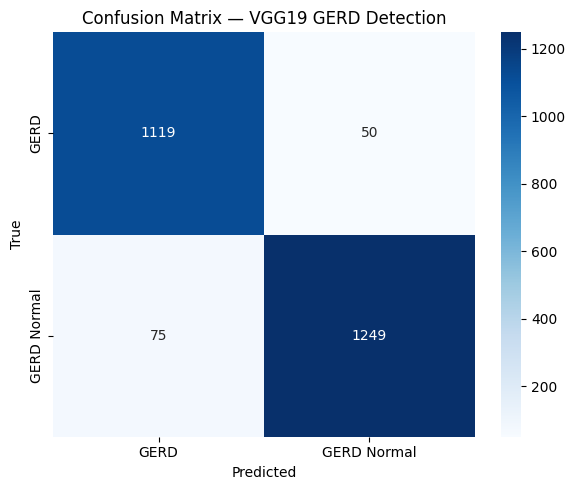

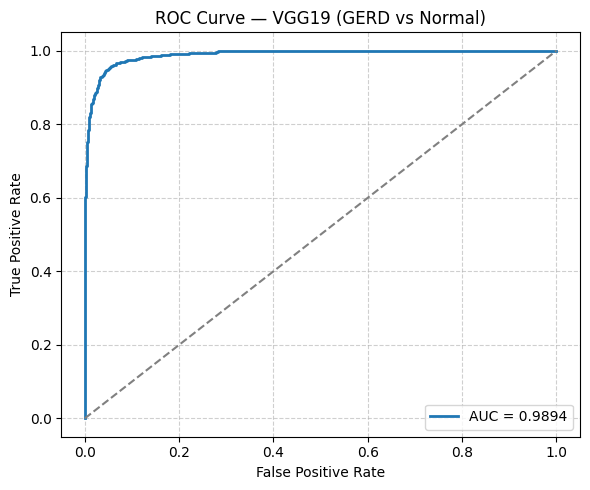

📈 Final AUC: 0.9894
🔎 Brier score: 0.039182  (lower is better)


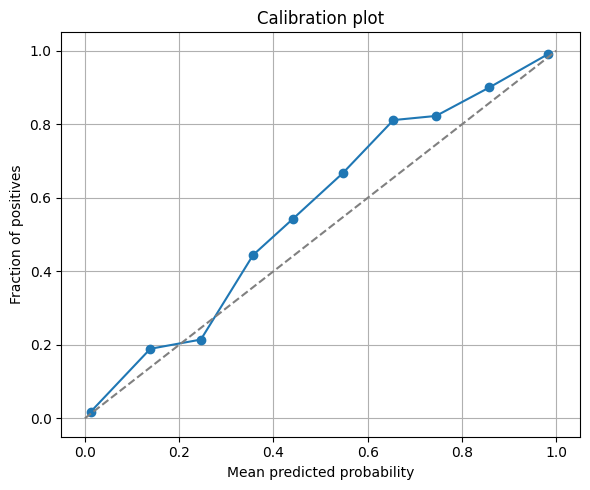

78/78 ━━━━━━━━━━━━━━━━━━━━ 19s 228ms/step - accuracy: 0.9486 - loss: 0.1325
✅ Test Accuracy: 0.9499
✅ Test Loss: 0.1347


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    brier_score_loss
)
from sklearn.calibration import calibration_curve

# Predictions
y_pred = model.predict(test_gen, verbose=1)
y_pred_cls = (y_pred > 0.5).astype(int).reshape(-1)
y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# Classification report
print("\n📊 Classification Report:\n")
print(classification_report(y_true, y_pred_cls,
                            target_names=class_labels,
                            digits=4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_cls)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title("Confusion Matrix — VGG19 GERD Detection")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# ROC & AUC
fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — VGG19 (GERD vs Normal)")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

print(f"📈 Final AUC: {roc_auc:.4f}")

# 🔹 Brier Score (probability calibration metric)
brier = brier_score_loss(y_true, y_pred.reshape(-1))
print(f"🔎 Brier score: {brier:.6f}  (lower is better)")

# Calibration curve
prob_true, prob_pred = calibration_curve(y_true,
                                         y_pred.reshape(-1),
                                         n_bins=10)
plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration plot')
plt.grid(True)
plt.tight_layout()
plt.show()

# Final test accuracy & loss
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f"✅ Test Accuracy: {test_acc:.4f}")
print(f"✅ Test Loss: {test_loss:.4f}")


In [10]:
# Install SHAP (only first time; ignore warning if already installed)
!pip install shap --quiet


Computed SHAP values.


<Figure size 600x600 with 0 Axes>

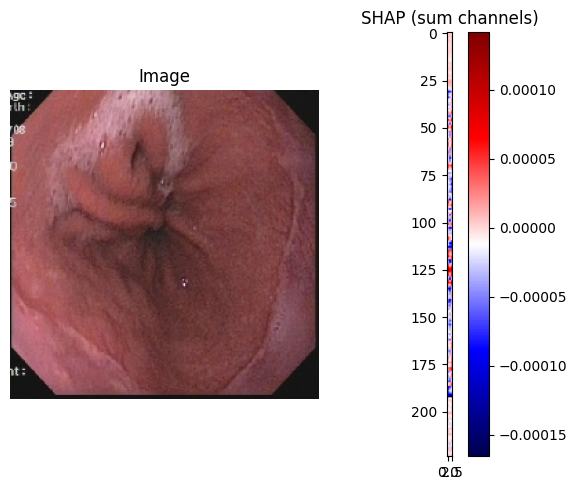

<Figure size 600x600 with 0 Axes>

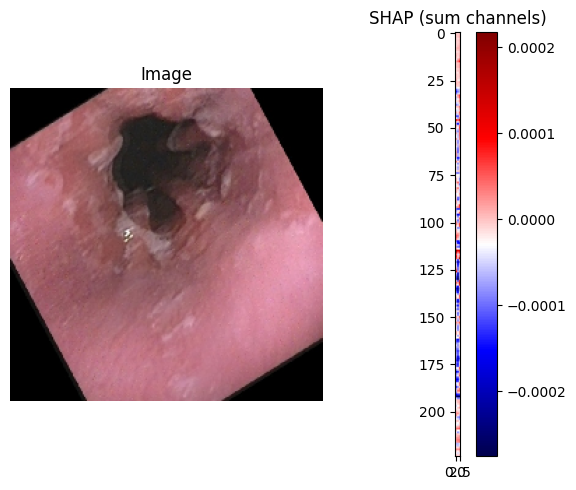

<Figure size 600x600 with 0 Axes>

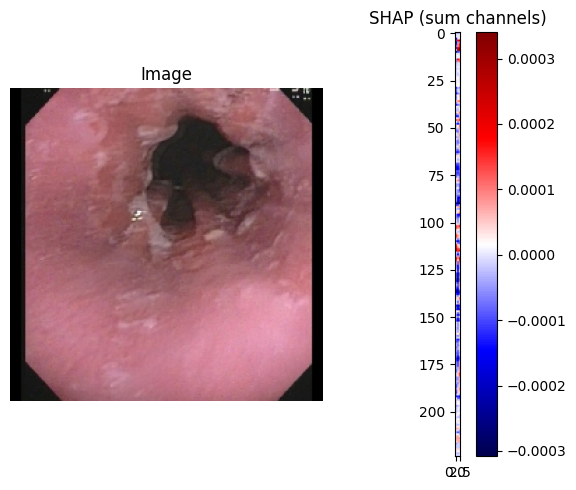

<Figure size 600x600 with 0 Axes>

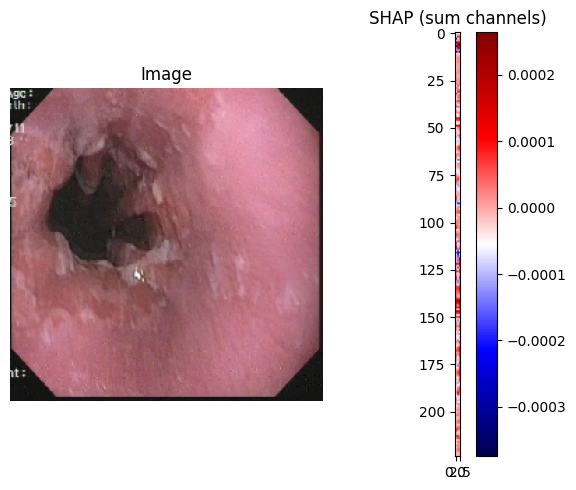

<Figure size 600x600 with 0 Axes>

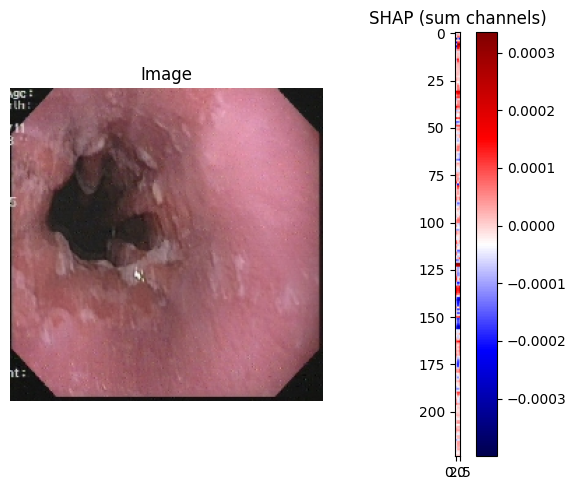

<Figure size 600x600 with 0 Axes>

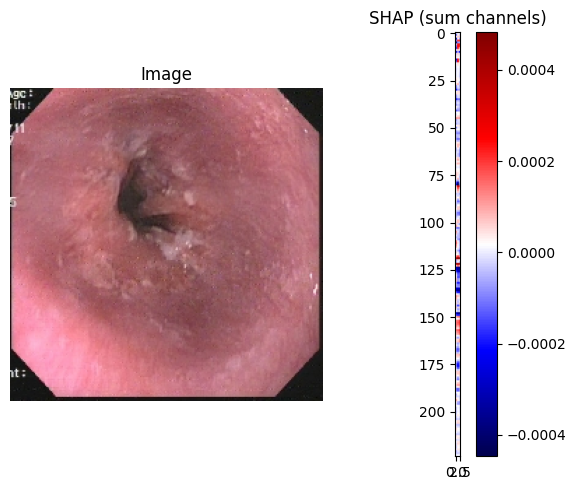

<Figure size 600x600 with 0 Axes>

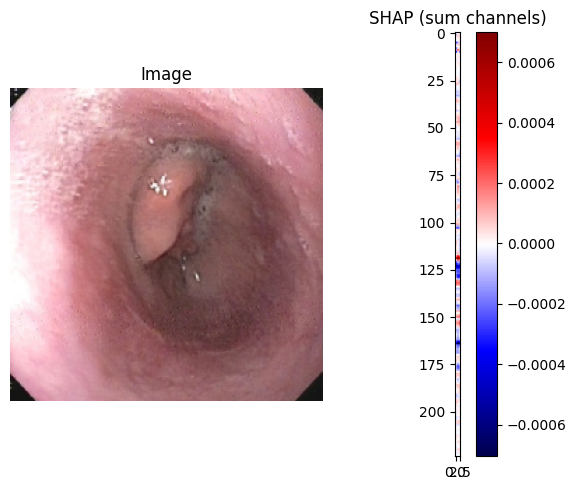

<Figure size 600x600 with 0 Axes>

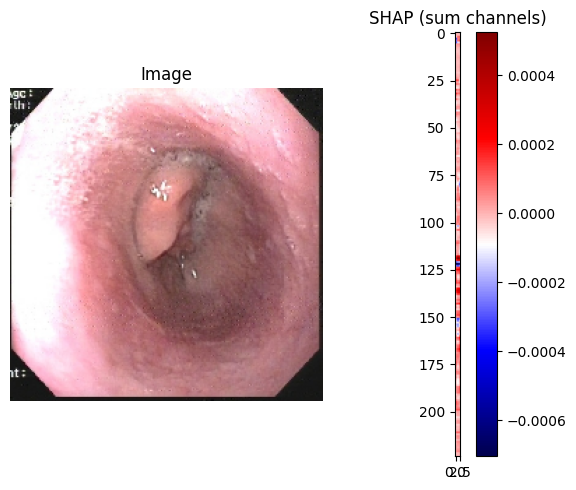

✅ SHAP explanations generated for sample images.


In [11]:
import shap
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# ⚠️ SHAP is heavy — keep background & sample sizes small
n_samples = 8
filepaths = [test_gen.filepaths[i] for i in range(min(n_samples, len(test_gen.filepaths)))]

# Background: small subset of training images
background = []
num_bg = min(50, len(train_gen.filepaths))
for i in np.random.choice(len(train_gen.filepaths), size=num_bg, replace=False):
    img = image.load_img(train_gen.filepaths[i], target_size=(224,224))
    arr = image.img_to_array(img) / 255.0
    background.append(arr)
background = np.array(background)

# Test samples
X_test_samples = []
for fp in filepaths:
    img = image.load_img(fp, target_size=(224,224))
    arr = image.img_to_array(img) / 255.0
    X_test_samples.append(arr)
X_test_samples = np.array(X_test_samples)

# SHAP explainer (GradientExplainer works with TF models)
explainer = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(X_test_samples)

print("Computed SHAP values.")

# Plot SHAP explanations
for i in range(len(X_test_samples)):
    plt.figure(figsize=(6,6))
    try:
        # shap.image_plot expects [shap_values], and image batch
        shap.image_plot([shap_values[0][i]], -X_test_samples[i:i+1])
    except Exception as e:
        # Fallback: simple heatmap
        img = X_test_samples[i]
        sv = np.sum(shap_values[0][i], axis=2)
        plt.subplot(1,2,1); plt.imshow(img); plt.axis('off'); plt.title('Image')
        plt.subplot(1,2,2); plt.imshow(sv, cmap='seismic'); plt.colorbar(); plt.title('SHAP (sum channels)')
        plt.tight_layout()
    plt.show()

print("✅ SHAP explanations generated for sample images.")


In [12]:
SAVE_PATH = "/content/drive/MyDrive/vgg19_gerd_final_finetuned_95acc.h5"

try:
    model.save(SAVE_PATH)
    print(f"✅ Model saved successfully at: {SAVE_PATH}")
except Exception as e:
    print(f"❌ Error while saving model: {e}")


✅ Model saved successfully at: /content/drive/MyDrive/vgg19_gerd_final_finetuned_95acc.h5
